In [81]:
import sqlite3 as sq3
import pandas as pd
import matplotlib.pyplot as plt
import rpy2
import rpy2.robjects as ro
from rpy2.robjects import numpy2ri
import rpy2.rinterface as ri
from rpy2.robjects.packages import importr
from rpy2.robjects.conversion import localconverter

In [31]:
con = sq3.connect('opioid.db')
sql = con.cursor()

for row in sql.execute("select * from county_info limit 5;"):
    print(row)

con.close()

('1', 'AUTAUGA', 'AL', '01001', '1', '1', 'Autauga', 'Autauga County, Alabama', 'B01003_001', '2006', '51328', 'Autauga, AL', '594.44')
('2', 'BALDWIN', 'AL', '01003', '1', '3', 'Baldwin', 'Baldwin County, Alabama', 'B01003_001', '2006', '168121', 'Baldwin, AL', '1589.78')
('3', 'BARBOUR', 'AL', '01005', '1', '5', 'Barbour', 'Barbour County, Alabama', 'B01003_001', '2006', '27861', 'Barbour, AL', '884.88')
('4', 'BIBB', 'AL', '01007', '1', '7', 'Bibb', 'Bibb County, Alabama', 'B01003_001', '2006', '22099', 'Bibb, AL', '622.58')
('5', 'BLOUNT', 'AL', '01009', '1', '9', 'Blount', 'Blount County, Alabama', 'B01003_001', '2006', '55485', 'Blount, AL', '644.78')


In [32]:
con = sq3.connect('opioid.db')
county_info = pd.read_sql_query("SELECT * FROM county_info", con)
con.close()
county_info.head()

,?,BUYER_COUNTY,BUYER_STATE,countyfips,STATE,COUNTY,county_name,NAME,variable,year,population,Areaname,LND110210D
0,1,AUTAUGA,AL,01001,1,1,Autauga,"Autauga County, Alabama",B01003_001,2006,51328,"Autauga, AL",594.44
1,2,BALDWIN,AL,01003,1,3,Baldwin,"Baldwin County, Alabama",B01003_001,2006,168121,"Baldwin, AL",1589.78
2,3,BARBOUR,AL,01005,1,5,Barbour,"Barbour County, Alabama",B01003_001,2006,27861,"Barbour, AL",884.88
3,4,BIBB,AL,01007,1,7,Bibb,"Bibb County, Alabama",B01003_001,2006,22099,"Bibb, AL",622.58
4,5,BLOUNT,AL,01009,1,9,Blount,"Blount County, Alabama",B01003_001,2006,55485,"Blount, AL",644.78


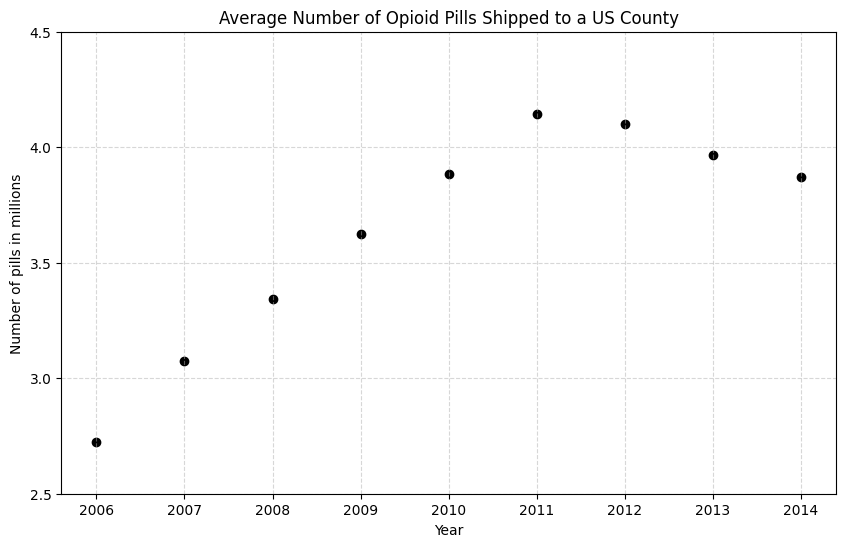

In [63]:
con = sq3.connect('opioid.db')
annual = pd.read_sql_query("SELECT * FROM annual", con)
land = pd.read_sql_query("SELECT * FROM land", con)
population = pd.read_sql_query("SELECT * FROM population", con)
con.close()
land = land.rename(columns={'STCOU': 'countyfips'})

for df in [annual, population, land]:
    df['countyfips'] = df['countyfips'].astype(str)
df = pd.merge(annual, population, on=['countyfips', 'year'])
df = pd.merge(df, land, on='countyfips')

df['DOSAGE_UNIT'] = pd.to_numeric(df['DOSAGE_UNIT'])
df['year'] = pd.to_numeric(df['year'])
df = df.dropna(subset=['DOSAGE_UNIT', 'year'])
avg = df.groupby('year')['DOSAGE_UNIT'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(avg['year'], avg['DOSAGE_UNIT']/1000000, color='black')
plt.title('Average Number of Opioid Pills Shipped to a US County')
plt.xlabel('Year')
plt.ylabel('Number of pills in millions')
plt.yticks([2.5, 3.0, 3.5, 4.0, 4.5])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
r = """
raw <- sample(0:1000, 500, replace = TRUE)
data <- matrix(raw, nrow = 5, ncol = 100)
avg <- rowMeans(data)
avg
"""

with localconverter(ro.default_converter + numpy2ri.converter):
    result = ro.r(r)
print(result)

[504.36 528.38 452.31 502.7  480.69]
